## Gaussian Processes

In [ ]:
%pip install pymc pytensor

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pymc as pm

### Covariance Functions and Kernel

In [ ]:
def exp_quad_kernel(x,knots,l=1):
  return np.array([np.exp(-(x-k)**2/(2*l**2)) for k in knots])

In [ ]:
data = np.array([-1,0,1,2])
#data = np.array([-1,0])
cov = exp_quad_kernel(data,data,1)



In [ ]:
print(cov)

[[1.         0.60653066 0.13533528 0.011109  ]
 [0.60653066 1.         0.60653066 0.13533528]
 [0.13533528 0.60653066 1.         0.60653066]
 [0.011109   0.13533528 0.60653066 1.        ]]


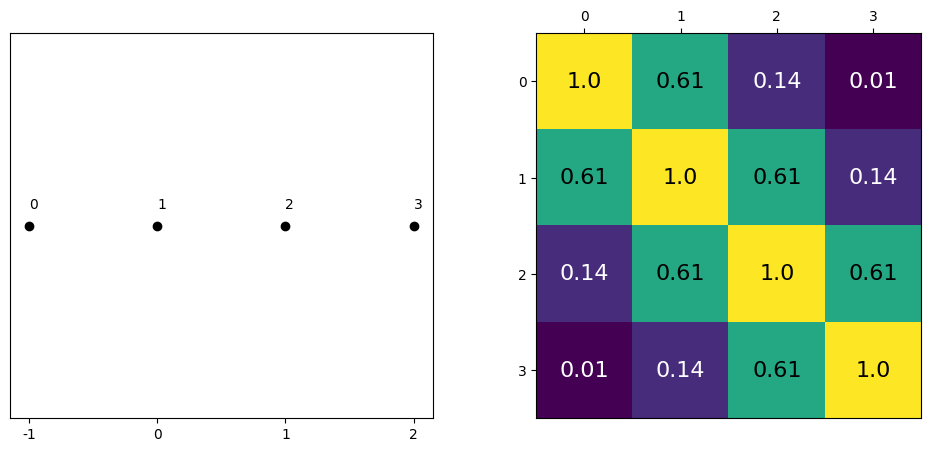

In [ ]:
_, ax=plt.subplots(1,2,figsize=(12,5))

ax[0].plot(data, np.zeros_like(data),'ko')
ax[0].set_yticks([])

for idx,i in enumerate(data):
  ax[0].text(i,0+0.005, idx)
ax[0].set_xticks(data)
ax[0].set_xticklabels(np.round(data,2))

ax[1].grid(False)
im = ax[1].imshow(cov)
colors=['w','k']

for i in range(len(cov)):
  for j in range(len(cov)):
    ax[1].text(i,j, round(cov[i,j],2), color=colors[int(im.norm(cov[i,j])>0.5)], ha = 'center', va='center', fontdict={'size':16})

ax[1].set_xticks(range(len(data)))
ax[1].set_yticks(range(len(data)))
ax[1].xaxis.tick_top()

Text(-0.03, 0.5, 'f(x)')

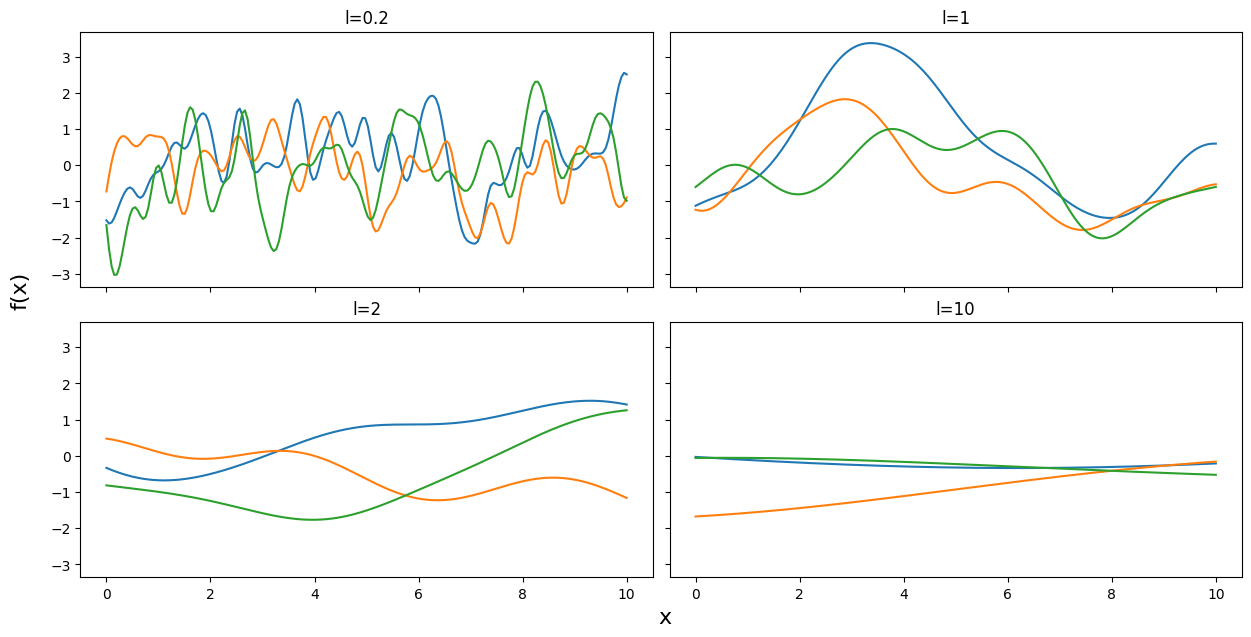

In [ ]:

np.random.seed(24)
test_points = np.linspace(0,10,200)
fig, ax = plt.subplots(2,2,figsize=(12,6),sharex=True,sharey=True,constrained_layout=True)
ax = np.ravel(ax)
for idx, l in enumerate((0.2,1,2,10)):
  cov = exp_quad_kernel(test_points, test_points, l)
  ax[idx].plot(test_points, stats.multivariate_normal.rvs(cov=cov,size=3).T)
  ax[idx].set_title(f'l={l}')

fig.text(0.51,-0.03,'x', fontsize=16)
fig.text(-0.03,0.5,'f(x)', fontsize=16, rotation=90)




### Gaussian Processes: Implementation


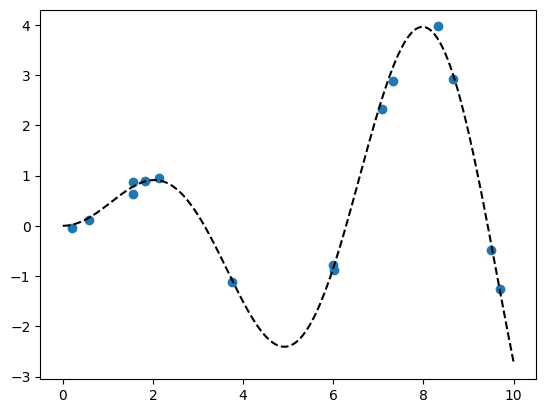

In [ ]:
np.random.seed(42)

x = np.random.uniform(0,10,size=15)

scale = 0.50
y = np.random.normal(scale*x*np.sin(x), 0.1)

plt.plot(x,y,'o')

true_x = np.linspace(0,10,200)
true_y = scale*true_x*np.sin(true_x)
plt.plot(true_x,true_y, 'k--')


In [ ]:
X = x[:,None]

with pm.Model() as model_reg:
  #hyperprior for lengthscale kernel parameter
  l = pm.Gamma('l',2,0.5)
  #instantiate a covariance function
  cov = pm.gp.cov.ExpQuad(1,ls=l)
  #mean = pm.gp.mean.Constant(c=0)
  #instantiate a GP prior
  gp = pm.gp.Marginal(cov_func=cov)#mean_func=mean,
  #prior
  eps = pm.HalfNormal('eps',25)
  #likelihood
  y_pred = gp.marginal_likelihood('y_pred',X=X, y=y, sigma=eps)
  trace_reg = pm.sample(2000, return_inferencedata=True, target_accept=0.95)

Output()

**Notes**

In GP regression, the marginal likelihood is the probability of the observed data after integrating out (analytically) the unknown function values.
The marginal likelihood is needed for two main reasons.

1. It  defines the likelihood used to infer the GP hyperparameters

2. It is the basis for making predictions at new points.



array([[<Axes: title={'center': 'eps'}>, <Axes: title={'center': 'eps'}>],
       [<Axes: title={'center': 'l'}>, <Axes: title={'center': 'l'}>]],
      dtype=object)

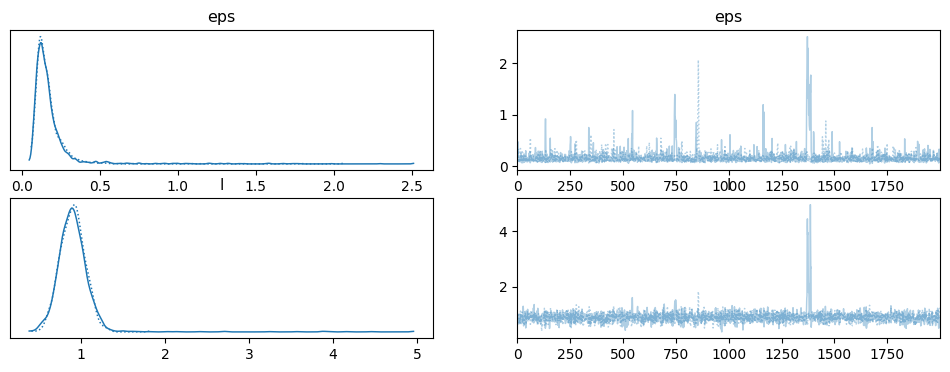

In [ ]:
import arviz as az
az.plot_trace(trace_reg)

In [ ]:
az.summary(trace_reg)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
eps,0.177,0.145,0.069,0.312,0.008,0.036,1640.0,752.0,1.0
l,0.907,0.215,0.626,1.198,0.009,0.043,1552.0,1387.0,1.0


In [ ]:
X_new = np.linspace(np.floor(x.min()), np.ceil(x.max()), 100)[:,None]

with model_reg:
    #del marginal_gp_model.named_vars['f_pred']
    #marginal_gp_model.vars.remove(f_pred)
    f_pred = gp.conditional('f_pred', X_new)

In [ ]:
with model_reg:
    pred_samples = pm.sample_posterior_predictive(trace_reg, var_names=['f_pred'])

Output()

In [ ]:
pred_samples

Inference data with groups:
	> posterior_predictive
	> observed_data

**Analytic GP prediction at one hyperparameter point**

Text(0.5, 0, 'X')

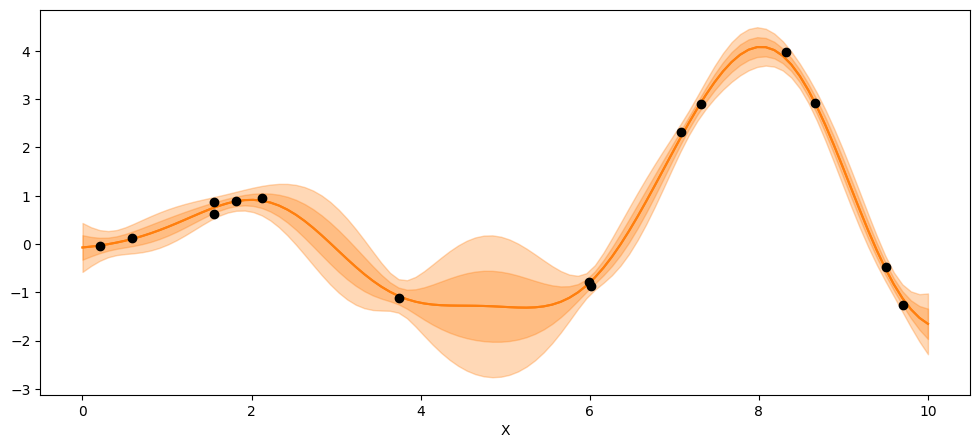

In [ ]:
_, ax = plt.subplots(figsize=(12,5))
point = {'l': trace_reg.posterior['l'].mean(), 'eps':trace_reg.posterior['eps'].mean()}


# Xnew: The new input locations where you want to predict the function values.
# point: A dictionary containing the parameter values to evaluate the GP at (e.g., length scale, amplitude).
#        If None, PyMC uses the default values defined in your model.
# diag: If True, returns only the diagonal of the covariance matrix instead of the full covariance.

mu, var = gp.predict(X_new, point=point, diag=True, model = model_reg)
sd = var**0.5

ax.plot(X_new,mu,'C1')
ax.fill_between(X_new.flatten(),mu-sd,mu+sd, color="C1",alpha=0.3)

ax.plot(X_new,mu,'C1')
ax.fill_between(X_new.flatten(),mu-2*sd,mu+2*sd, color="C1",alpha=0.3)

ax.plot(X,y,'ko')
ax.set_xlabel('X')

**Posterior predictive function samples**

In [ ]:
print(np.shape(pred_samples.posterior_predictive['f_pred'].mean(axis=0).T))
print(np.shape(X_new))

(100, 2000)
(100, 1)


Text(0.5, 0, 'X')

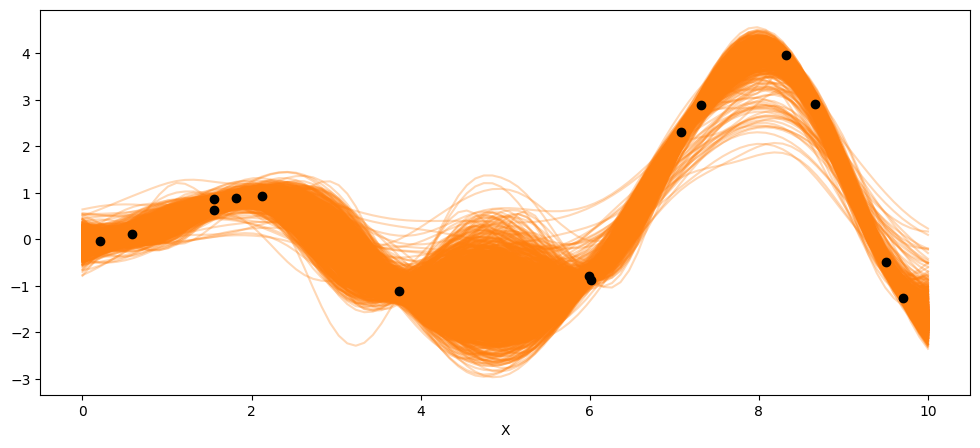

In [ ]:
_, ax = plt.subplots(figsize=(12,5))
ax.plot(X_new, pred_samples.posterior_predictive['f_pred'].mean(axis=0).T, 'C1-', alpha=0.3)
ax.plot(X, y, 'ko')
ax.set_xlabel('X')

Text(0, 0.5, 'f(x)')

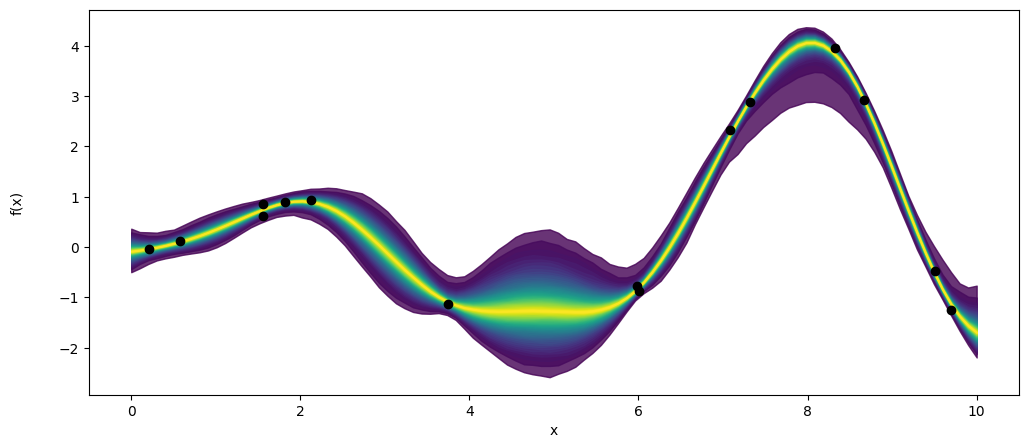

In [ ]:
_, ax = plt.subplots(figsize=(12,5))
pm.gp.util.plot_gp_dist(ax, pred_samples.posterior_predictive['f_pred'].mean(axis=0), X_new, palette='viridis',plot_samples=False)

ax.plot(X,y,'ko')
ax.set_xlabel('x')
ax.set_ylabel('f(x)',labelpad=25)